## MARBL diagnostics, compare timeseries of global metrics between multiple cases (only 2-d variables)


In [1]:
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import os
from glob import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cftime
import pandas as pd
import matplotlib.gridspec as gridspec
from xgcm import Grid
xr.set_options(keep_attrs=True);

### Come up with short names for each case

In [2]:
short_names = ['005'
              ]

### Define number of years and number of cases

In [3]:
num_cases = len(short_names)
num_years = 15 #max years in any of the runs

### Define cases

In [4]:
sandbox = 'g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37'

case_nums = ['005']

user = 'klindsay'

### Define the year range

In [5]:
start_yr = 37
endyr = start_yr + num_years 

### 2-D variable list

In [6]:
variables2d = ['calcToSed','pocToSed','DIC_RIV_FLUX','DOC_RIV_FLUX','DOCR_RIV_FLUX'] 

coords = {'x':'yh','y':'xh'}


keepthese=['z_l','z_i','time_bounds','time','average_T1', 'average_T2','average_DT'] + variables2d + list(coords.values())

### Get dask going

In [7]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=2,
        memory='25 GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=25GB',
        project='NCGD0011',
        walltime='03:00:00',
        interface='ext',
        log_directory='./dask-logs')

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [8]:
cluster, client = get_ClusterClient()
cluster.scale(12) 
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.178:34739,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kristenk/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Read in all the data

In [11]:
cases_dict = {}

for case_num in case_nums:
    case = sandbox + '.' + case_num
    print(case)
    files = []
    for year in range(start_yr,endyr):
        yr4="{:04d}".format(year)
        #print('doing simulation year', year, '!')
        
        files.extend(sorted(glob(f'/glade/derecho/scratch/{user}/archive/{case}/ocn/hist/{case}.mom6.h.bgc.native_annual.{yr4}.nc')))
    ds_tmp = xr.open_mfdataset(files,decode_times=True,decode_coords=False, concat_dim='time',combine='nested' )
    ### drop unnecessary variables
    ds_tmp = ds_tmp.drop([v for v in ds_tmp.variables if v not in keepthese])
    ### resample to annual means
    cases_dict[case_num] = ds_tmp #.resample({'time':'A'}).mean(dim='time', keep_attrs=True).compute()

g.e30_a09e.GW1850MARBL_CPLHIST_PHYS_CYCLE.ne30pg3_t233_wg37.005


In [12]:
cases_dict.keys()

dict_keys(['005'])

## Get the grid data for MOM6

In [13]:
ds_grid = xr.open_dataset(f'/glade/work/kristenk/cesm_work/mom6_static_files/g.e23b16.TL319_t232.GIAFMARBL.001.mom6.h.static.nc')

In [14]:
lons = ds_grid.geolon
lats = ds_grid.geolat
area = ds_grid.areacello #m2

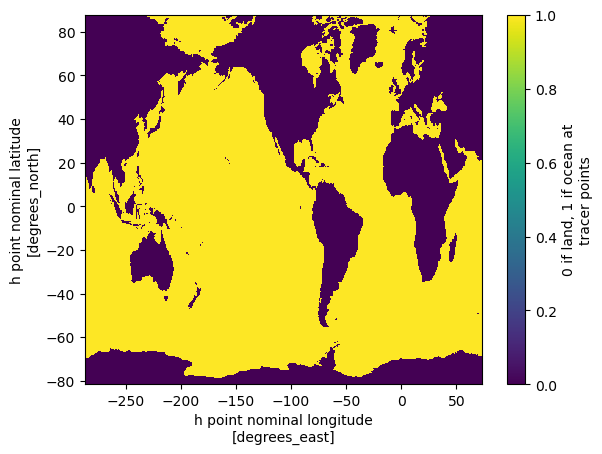

In [15]:
ds_grid.wet.plot()

### Global totals

In [17]:
mmols_to_PgCyr = 1e-3 * 12. * 1e-15 * 365. * 86400.

variables = variables2d

glb_ds_dict = {}

for case_num in case_nums:
    
    case = sandbox + '.' + case_num

    ds_glb = xr.Dataset()

    ds = cases_dict[case_num]
    
    for v in variables:
        ds_glb[v] = ((ds[v] * area).sum(dim=('xh', 'yh'))).compute() #mmol/m
        ds_glb[v].attrs = ds[v].attrs
    
        ds_glb[v] = ds_glb[v] * mmols_to_PgCyr        
        ds_glb[v].attrs['units'] = 'Pg C yr$^{-1}$'

    
    ds_glb = ds_glb.compute()

    glb_ds_dict[case_num] = ds_glb

In [18]:
mean_glb_dict = {}

for case in cases_dict.keys():
    print(case)

    mean_glb_dict[case] = glb_ds_dict[case].isel(time=slice(-10, None)).mean(dim="time")

005


In [19]:
for case in case_nums:

    print(case)
    print('--------------')
    print('calcToSed = ', mean_glb_dict[case].calcToSed.values, ' Pg C yr$^{-1}$')
    print('pocToSed = ', mean_glb_dict[case].pocToSed.values, ' Pg C yr$^{-1}$')
    print('DIC_RIV_FLUX = ',mean_glb_dict[case].DIC_RIV_FLUX.values, ' Pg C yr$^{-1}$')
    print('DOC_RIV_FLUX = ',mean_glb_dict[case].DOC_RIV_FLUX.values, ' Pg C yr$^{-1}$')
    print('DOCR_RIV_FLUX = ',mean_glb_dict[case].DOCR_RIV_FLUX.values, ' Pg C yr$^{-1}$')
    print()
    print('TOTAL OUT = ', mean_glb_dict[case].calcToSed.values+mean_glb_dict[case].pocToSed.values)
    print('TOTAL IN = ', mean_glb_dict[case].DIC_RIV_FLUX.values+mean_glb_dict[case].DOC_RIV_FLUX.values+mean_glb_dict[case].DOCR_RIV_FLUX.values)
    print()
    print('BALANCE = ',(mean_glb_dict[case].DIC_RIV_FLUX.values+mean_glb_dict[case].DOC_RIV_FLUX.values+mean_glb_dict[case].DOCR_RIV_FLUX.values)-(mean_glb_dict[case].calcToSed.values+mean_glb_dict[case].pocToSed.values))

005
--------------
calcToSed =  0.13171516358852386  Pg C yr$^{-1}$
pocToSed =  0.14445777237415314  Pg C yr$^{-1}$
DIC_RIV_FLUX =  0.26456931233406067  Pg C yr$^{-1}$
DOC_RIV_FLUX =  0.13883820176124573  Pg C yr$^{-1}$
DOCR_RIV_FLUX =  0.03470955044031143  Pg C yr$^{-1}$

TOTAL OUT =  0.276172935962677
TOTAL IN =  0.43811706453561783

BALANCE =  0.16194412857294083


### Make some timeseries plots for global BGC metrics

In [22]:
st_yr = 37

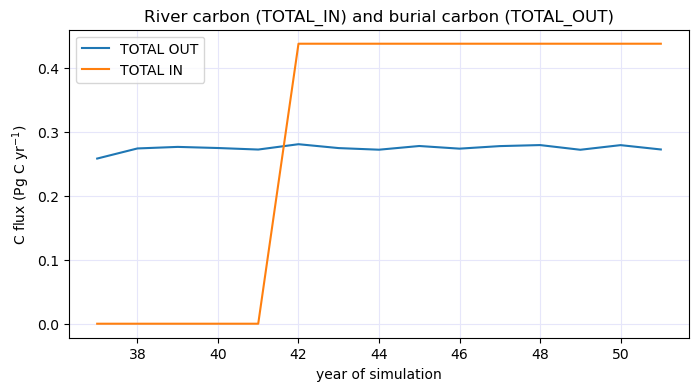

In [28]:
fig = plt.figure(figsize=(8,4))

####################
ax = fig.add_subplot(1,1,1)
ax.set_title('River carbon (TOTAL_IN) and burial carbon (TOTAL_OUT)')

i = 0

for case_num in case_nums:
    TOTAL_OUT = glb_ds_dict[case].calcToSed.values + glb_ds_dict[case].pocToSed.values
    TOTAL_IN = glb_ds_dict[case].DIC_RIV_FLUX.values + glb_ds_dict[case].DOC_RIV_FLUX.values + glb_ds_dict[case].DOCR_RIV_FLUX.values
    years = np.arange(st_yr,st_yr+len(glb_ds_dict[case_num].time),1)
    ax.plot(years,TOTAL_OUT,label='TOTAL OUT')
    ax.plot(years,TOTAL_IN,label='TOTAL IN')
    i = i + 1

ax.xaxis.grid(True, which='major',color='lavender')
ax.yaxis.grid(False, which='major',color='lavender');

ax.legend()
ax.set(ylabel='C flux (Pg C yr$^{-1}$)',xlabel='year of simulation');
